<a href="https://colab.research.google.com/github/adelinewidyatmoko/ProjectA_Kelompok6_BanjirArticles_PBA/blob/main/notebooks/06_sentiment_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Classification — Banjir Biasa vs Banjir Bandang

Notebook ini mengklasifikasikan berita banjir ke dalam dua kategori: Banjir Biasa dan Banjir Bandang, menggunakan dua pendekatan yang kemudian dibandingkan hasilnya.

**Alur:**
1. Load data
2. Keyword-based Classification
3. Naive Bayes Classification (berbasis TF-IDF matrix)
4. Perbandingan hasil kedua metode
5. Kesimpulan

## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print('Library siap!')

Library siap!


## 1. Load Data

In [3]:
# upload file kalau di Colab
# from google.colab import files
# files.upload()  # upload data_banjir_clean.csv, tfidf_matrix.csv, tfidf_top_kata.csv

df_clean  = pd.read_csv('data_banjir_clean.csv')
df_matrix = pd.read_csv('tfidf_matrix.csv')
df_top    = pd.read_csv('tfidf_top_kata.csv')

print(f'data_banjir_clean  : {df_clean.shape}')
print(f'tfidf_matrix       : {df_matrix.shape}')
print(f'tfidf_top_kata     : {df_top.shape}')
print()
print('Label ground truth (manual):')
print(df_clean['Sentimen'].value_counts())
print()
print('Label di TF-IDF matrix:')
print(df_matrix['kategori'].value_counts())

data_banjir_clean  : (1571, 7)
tfidf_matrix       : (1654, 501)
tfidf_top_kata     : (40, 3)

Label ground truth (manual):
Sentimen
Bandang    909
Banjir     662
Name: count, dtype: int64

Label di TF-IDF matrix:
kategori
Banjir Bandang    971
Banjir Biasa      683
Name: count, dtype: int64


## 2. Keyword-based Classification

Pendekatan ini mengklasifikasikan artikel berdasarkan ada tidaknya kata kunci yang mencirikan masing-masing kategori banjir. Tidak memerlukan proses training — cukup mencocokkan teks dengan daftar kata kunci yang ditentukan secara manual.

In [4]:
# kata kunci yang mencirikan banjir bandang (lebih spesifik, diprioritaskan)
keyword_bandang = [
    'banjir bandang', 'bandang', 'terseret', 'menghanyutkan', 'menerjang',
    'meninggal', 'korban jiwa', 'tewas', 'longsor', 'hancur',
    'rusak berat', 'roboh', 'tertimbun', 'material', 'lumpur'
]

# kata kunci yang mencirikan banjir biasa
keyword_biasa = [
    'terendam', 'genangan', 'mengungsi', 'pengungsi', 'surut',
    'meluap', 'rob', 'drainase', 'ketinggian air', 'banjir kiriman',
    'tergenang', 'macet', 'lumpuh'
]

def klasifikasi_keyword(teks):
    if not isinstance(teks, str):
        return 'Tidak Diketahui'
    teks = teks.lower()

    # bandang dicek duluan karena lebih spesifik
    skor_bandang = sum(1 for k in keyword_bandang if k in teks)
    skor_biasa   = sum(1 for k in keyword_biasa if k in teks)

    if skor_bandang > skor_biasa:
        return 'Banjir Bandang'
    elif skor_biasa > skor_bandang:
        return 'Banjir Biasa'
    elif skor_bandang == skor_biasa and skor_bandang > 0:
        return 'Banjir Bandang'  # prioritas bandang kalau skor sama
    else:
        return 'Tidak Diketahui'

df_clean['prediksi_keyword'] = df_clean['Konten'].apply(klasifikasi_keyword)

print('Distribusi hasil keyword-based:')
print(df_clean['prediksi_keyword'].value_counts())

Distribusi hasil keyword-based:
prediksi_keyword
Banjir Bandang     770
Banjir Biasa       691
Tidak Diketahui    110
Name: count, dtype: int64


In [5]:
# evaluasi keyword-based vs label manual
# samakan format label dulu
df_eval = df_clean[df_clean['prediksi_keyword'] != 'Tidak Diketahui'].copy()
df_eval['label_manual'] = df_eval['Sentimen'].map({'Banjir': 'Banjir Biasa', 'Bandang': 'Banjir Bandang'})

acc_keyword = accuracy_score(df_eval['label_manual'], df_eval['prediksi_keyword'])

print('=== EVALUASI KEYWORD-BASED ===')
print(f'Artikel terevaluasi : {len(df_eval)} dari {len(df_clean)}')
print(f'Tidak terklasifikasi: {len(df_clean) - len(df_eval)}')
print(f'Akurasi             : {acc_keyword*100:.2f}%')
print()
print('Classification Report:')
print(classification_report(df_eval['label_manual'], df_eval['prediksi_keyword']))

=== EVALUASI KEYWORD-BASED ===
Artikel terevaluasi : 1461 dari 1571
Tidak terklasifikasi: 110
Akurasi             : 84.05%

Classification Report:
                precision    recall  f1-score   support

Banjir Bandang       0.88      0.83      0.85       815
  Banjir Biasa       0.80      0.85      0.83       646

      accuracy                           0.84      1461
     macro avg       0.84      0.84      0.84      1461
  weighted avg       0.84      0.84      0.84      1461



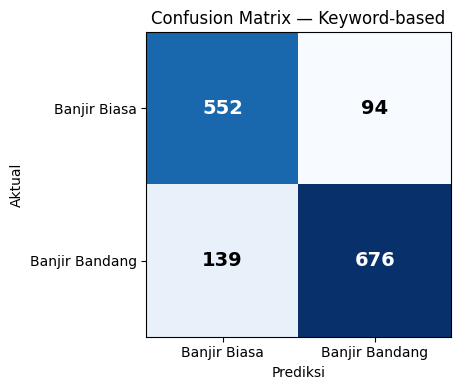

In [6]:
# confusion matrix keyword-based
cm_keyword = confusion_matrix(df_eval['label_manual'], df_eval['prediksi_keyword'],
                               labels=['Banjir Biasa', 'Banjir Bandang'])

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm_keyword, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Banjir Biasa', 'Banjir Bandang'])
ax.set_yticklabels(['Banjir Biasa', 'Banjir Bandang'])
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix — Keyword-based')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_keyword[i, j]), ha='center', va='center',
                color='white' if cm_keyword[i, j] > cm_keyword.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_keyword.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Naive Bayes Classification (TF-IDF)

Pendekatan ini menggunakan algoritma Naive Bayes yang dilatih pada representasi TF-IDF dari teks artikel. Model belajar dari sebagian data berlabel, kemudian diuji pada data yang belum pernah dilihat sebelumnya.

In [7]:
# pisahkan fitur (X) dan label (y) dari TF-IDF matrix
X = df_matrix.drop(columns=['kategori'])
y = df_matrix['kategori']

# pastikan semua nilai non-negatif (syarat MultinomialNB)
X = X.clip(lower=0)

print(f'Fitur (kata): {X.shape[1]}')
print(f'Sampel      : {X.shape[0]}')
print(f'Distribusi label:')
print(y.value_counts())

Fitur (kata): 500
Sampel      : 1654
Distribusi label:
kategori
Banjir Bandang    971
Banjir Biasa      683
Name: count, dtype: int64


In [8]:
# split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data training : {len(X_train)} sampel')
print(f'Data testing  : {len(X_test)} sampel')

Data training : 1323 sampel
Data testing  : 331 sampel


In [9]:
# training model
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

# prediksi pada data testing
y_pred = model_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred)

print('=== EVALUASI NAIVE BAYES ===')
print(f'Akurasi: {acc_nb*100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

=== EVALUASI NAIVE BAYES ===
Akurasi: 93.05%

Classification Report:
                precision    recall  f1-score   support

Banjir Bandang       0.94      0.94      0.94       194
  Banjir Biasa       0.91      0.92      0.92       137

      accuracy                           0.93       331
     macro avg       0.93      0.93      0.93       331
  weighted avg       0.93      0.93      0.93       331



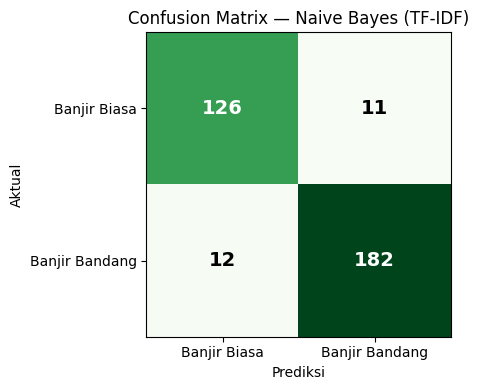

In [10]:
# confusion matrix Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred, labels=['Banjir Biasa', 'Banjir Bandang'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(cm_nb, cmap='Greens')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Banjir Biasa', 'Banjir Bandang'])
ax.set_yticklabels(['Banjir Biasa', 'Banjir Bandang'])
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix — Naive Bayes (TF-IDF)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_nb[i, j]), ha='center', va='center',
                color='white' if cm_nb[i, j] > cm_nb.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Perbandingan Kedua Metode

In [11]:
print('=' * 45)
print('PERBANDINGAN HASIL KLASIFIKASI')
print('=' * 45)
print(f'Keyword-based Accuracy : {acc_keyword*100:.2f}%')
print(f'Naive Bayes Accuracy   : {acc_nb*100:.2f}%')
print()
if acc_nb > acc_keyword:
    selisih = (acc_nb - acc_keyword) * 100
    print(f'Naive Bayes lebih akurat {selisih:.2f}% dibanding keyword-based.')
    print('Hal ini menunjukkan pendekatan machine learning lebih efektif')
    print('dalam menangkap pola linguistik yang kompleks pada teks berita banjir.')
else:
    selisih = (acc_keyword - acc_nb) * 100
    print(f'Keyword-based lebih akurat {selisih:.2f}% dibanding Naive Bayes.')
    print('Hal ini kemungkinan karena kata kunci yang dipilih sangat representatif')
    print('untuk membedakan kedua kategori banjir.')

PERBANDINGAN HASIL KLASIFIKASI
Keyword-based Accuracy : 84.05%
Naive Bayes Accuracy   : 93.05%

Naive Bayes lebih akurat 9.00% dibanding keyword-based.
Hal ini menunjukkan pendekatan machine learning lebih efektif
dalam menangkap pola linguistik yang kompleks pada teks berita banjir.


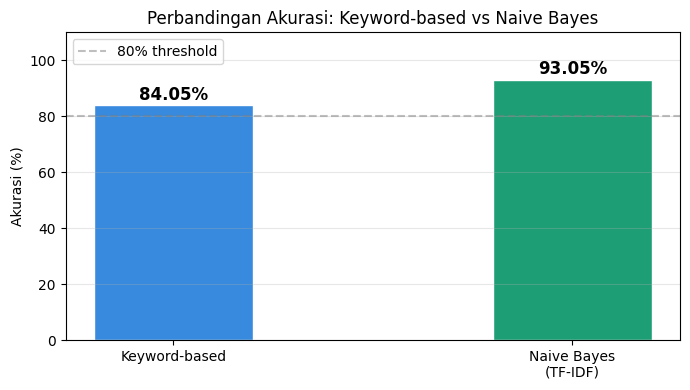

In [12]:
# visualisasi perbandingan akurasi
metode = ['Keyword-based', 'Naive Bayes\n(TF-IDF)']
akurasi = [acc_keyword * 100, acc_nb * 100]
warna = ['#378ADD', '#1D9E75']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metode, akurasi, color=warna, edgecolor='white', width=0.4)

for bar, val in zip(bars, akurasi):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Akurasi (%)')
ax.set_title('Perbandingan Akurasi: Keyword-based vs Naive Bayes')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Kata per Kategori (dari TF-IDF)

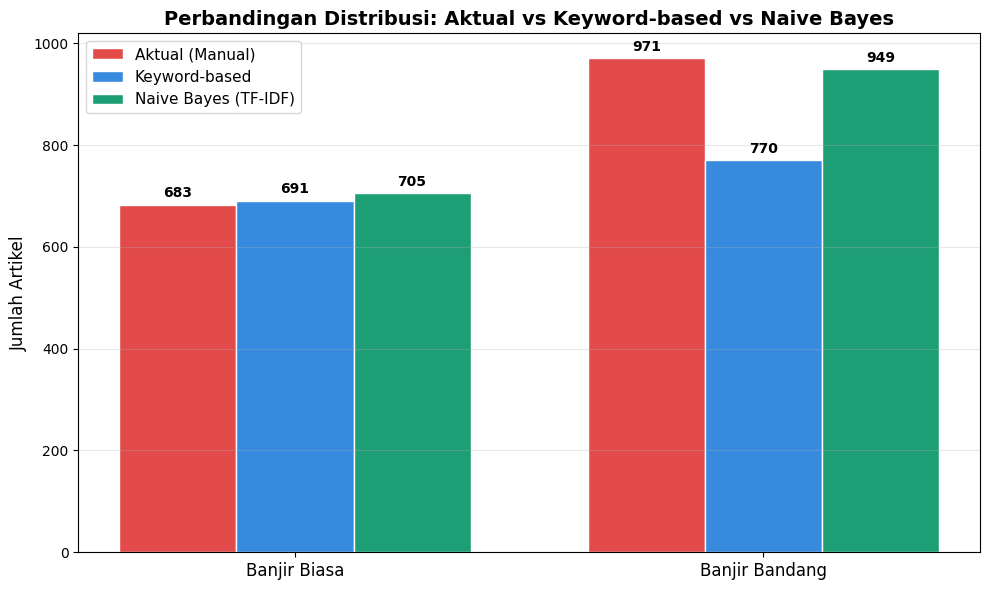

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ambil distribusi data aktual (manual labeling) dari target 'y'
dist_aktual = y.value_counts()

# 2. Ambil distribusi dari hasil Keyword-based yang sudah ada di df_clean
dist_keyword = df_clean['prediksi_keyword'].value_counts()

# 3. Lakukan prediksi menggunakan Naive Bayes pada seluruh data (X)
prediksi_nb_all = model_nb.predict(X)
dist_nb = pd.Series(prediksi_nb_all).value_counts()

# 4. Siapkan data untuk plotting
kategori = ['Banjir Biasa', 'Banjir Bandang']

# Ambil jumlah masing-masing kategori, default ke 0 jika tidak ada
count_aktual = [dist_aktual.get('Banjir Biasa', 0), dist_aktual.get('Banjir Bandang', 0)]
count_keyword = [dist_keyword.get('Banjir Biasa', 0), dist_keyword.get('Banjir Bandang', 0)]
count_nb = [dist_nb.get('Banjir Biasa', 0), dist_nb.get('Banjir Bandang', 0)]

# 5. Setup Grafik Batang Berpasangan (3 Batang)
x = np.arange(len(kategori))  # Lokasi label
width = 0.25  # Lebar batang diperkecil agar pas untuk 3 bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot batang untuk Aktual, Keyword-based, dan Naive Bayes
rects1 = ax.bar(x - width, count_aktual, width, label='Aktual (Manual)', color='#E24B4A', edgecolor='white')
rects2 = ax.bar(x, count_keyword, width, label='Keyword-based', color='#378ADD', edgecolor='white')
rects3 = ax.bar(x + width, count_nb, width, label='Naive Bayes (TF-IDF)', color='#1D9E75', edgecolor='white')

# 6. Kustomisasi Label, Judul, dan Tampilan
ax.set_ylabel('Jumlah Artikel', fontsize=12)
ax.set_title('Perbandingan Distribusi: Aktual vs Keyword-based vs Naive Bayes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(kategori, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Fungsi untuk menambahkan anotasi angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset vertikal 3 points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
# plt.savefig('perbandingan_3_distribusi.png', dpi=150, bbox_inches='tight') # Uncomment untuk menyimpan gambar
plt.show()

## 6. Ringkasan Akhir

In [15]:
print('=' * 50)
print('RINGKASAN KLASIFIKASI SENTIMEN')
print('=' * 50)
print(f'Total data              : {len(df_clean)} artikel')
print(f'  Banjir Biasa (manual) : {len(df_clean[df_clean["Sentimen"]=="Banjir"])}')
print(f'  Banjir Bandang (manual): {len(df_clean[df_clean["Sentimen"]=="Bandang"])}')
print()
print('Akurasi Klasifikasi:')
print(f'  Keyword-based  : {acc_keyword*100:.2f}%')
print(f'  Naive Bayes    : {acc_nb*100:.2f}%')
print()
metode_terbaik = 'Naive Bayes' if acc_nb > acc_keyword else 'Keyword-based'
print(f'Metode terbaik: {metode_terbaik}')

RINGKASAN KLASIFIKASI SENTIMEN
Total data              : 1571 artikel
  Banjir Biasa (manual) : 662
  Banjir Bandang (manual): 909

Akurasi Klasifikasi:
  Keyword-based  : 84.05%
  Naive Bayes    : 93.05%

Metode terbaik: Naive Bayes
